# 04 Clean and Inspect Documents

Σε αυτό το notebook ελέγχονται και καθαρίζονται τα markdown αρχεία που προέκυψαν από το Docling. Ο στόχος είναι να αφαιρεθούν εμφανή extraction artifacts και να προετοιμαστεί συνεπές κείμενο για το chunking.

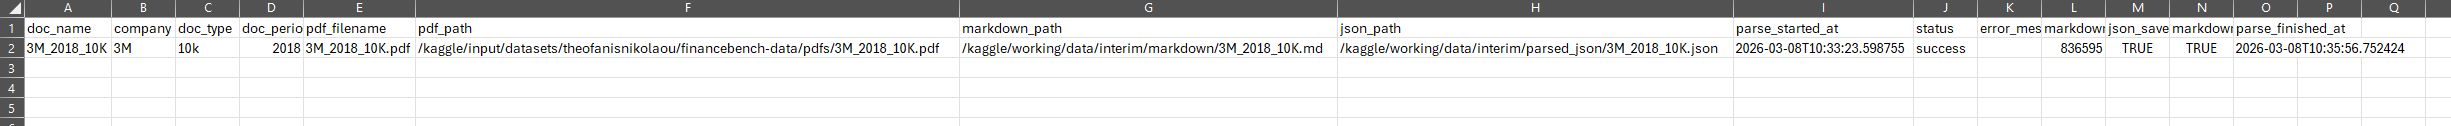

In [ ]:
from pathlib import Path
import re
import warnings

import pandas as pd
from tqdm.auto import tqdm


In [ ]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 140)

IN_KAGGLE = Path("/kaggle/working").exists()
print("IN_KAGGLE:", IN_KAGGLE)

In [ ]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = BASE_DIR / "data"
INTERIM_DIR = DATA_DIR / "interim"
OUTPUTS_DIR = BASE_DIR / "outputs"

MARKDOWN_DIR = INTERIM_DIR / "markdown"
CLEANED_DIR = INTERIM_DIR / "cleaned"
LOGS_DIR = OUTPUTS_DIR / "logs"

PARSE_MANIFEST_PATH = INTERIM_DIR / "docling_parse_manifest.csv"
CLEANING_MANIFEST_PATH = INTERIM_DIR / "markdown_cleaning_manifest.csv"

for p in [CLEANED_DIR, OUTPUTS_DIR, LOGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("MARKDOWN_DIR:", MARKDOWN_DIR)
print("CLEANED_DIR:", CLEANED_DIR)
print("PARSE_MANIFEST_PATH exists:", PARSE_MANIFEST_PATH.exists())

In [ ]:
parse_manifest_df = pd.read_csv(PARSE_MANIFEST_PATH)

print("parse_manifest_df shape:", parse_manifest_df.shape)
parse_manifest_df.head(2)

In [ ]:
successful_df = parse_manifest_df[parse_manifest_df["status"] == "success"].copy().reset_index(drop=True)

print("Successful parsed docs:", len(successful_df))
successful_df.head(2)

In [ ]:
md_files = sorted(MARKDOWN_DIR.glob("*.md"))

print("Markdown files found:", len(md_files))
for f in md_files[:10]:
    print("-", f.name)

In [ ]:
md_inventory = pd.DataFrame({
    "markdown_filename": [p.name for p in md_files],
    "markdown_path": [str(p) for p in md_files],
    "markdown_stem": [p.stem for p in md_files]
})

md_inventory.head()

In [ ]:
def read_text(path: Path) -> str:
    return path.read_text(encoding="utf-8")

In [ ]:
sample_path = md_files[0] if md_files else None

if sample_path:
    sample_text = read_text(sample_path)
    print("Sample file:", sample_path.name)
    print(sample_text[:4000])
else:
    print("No markdown files found.")

In [ ]:
md_inventory["char_count"] = md_inventory["markdown_path"].apply(lambda x: len(read_text(Path(x))))
md_inventory["line_count"] = md_inventory["markdown_path"].apply(lambda x: len(read_text(Path(x)).splitlines()))

md_inventory.describe(include="all")

In [ ]:
patterns = {
    "checkbox_unchecked": r"\- \[ \]",
    "checkbox_checked": r"\- \[x\]|\- \[X\]",
    "table_of_contents": r"table of contents",
    "standalone_page_number": r"^\s*\d+\s*$",
    "multiple_blank_lines": r"\n{3,}",
    "broken_spacing_word": r"[A-Za-z]+\s{2,}[A-Za-z]+",
}

pattern_counts = []

for _, row in md_inventory.iterrows():
    text = read_text(Path(row["markdown_path"]))
    lowered = text.lower()

    result = {"markdown_filename": row["markdown_filename"]}
    for pattern_name, pattern in patterns.items():
        source_text = lowered if pattern_name == "table_of_contents" else text
        result[pattern_name] = len(re.findall(pattern, source_text, flags=re.MULTILINE))
    pattern_counts.append(result)

pattern_df = pd.DataFrame(pattern_counts)
pattern_df.head()

In [ ]:
pattern_df.drop(columns=["markdown_filename"]).sum().to_frame("total_count")

In [ ]:
def get_matching_lines(text: str, pattern: str, max_lines: int = 20):
    matches = []
    for line in text.splitlines():
        if re.search(pattern, line, flags=re.IGNORECASE):
            matches.append(line)
        if len(matches) >= max_lines:
            break
    return matches

if sample_path:
    sample_text = read_text(sample_path)

    artifact_examples = {
        "checkbox": r"\- \[[xX ]\]",
        "table_of_contents": r"table of contents",
        "standalone_page_number": r"^\s*\d+\s*$",
    }

    for name, pattern in artifact_examples.items():
        print(f"\n{name.upper()} EXAMPLES")
        print("=" * 60)
        for line in get_matching_lines(sample_text, pattern):
            print(line)

In [ ]:
def clean_markdown(text: str) -> tuple[str, dict]:
    original_chars = len(text)
    original_lines = len(text.splitlines())

    stats = {
        "removed_checkbox_lines": 0,
        "removed_standalone_page_numbers": 0,
        "removed_low_lines": 0,
        "collapsed_blank_line_groups": 0,
        "trimmed_lines": 0,
    }

    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:
        original_line = line
        stripped = line.strip()

        # remove very noisy leading "low" lines
        if stripped.lower() == "low":
            stats["removed_low_lines"] += 1
            continue

        # remove checkbox lines
        if re.fullmatch(r"\- \[[xX ]\]", stripped):
            stats["removed_checkbox_lines"] += 1
            continue

        # remove standalone page numbers
        if re.fullmatch(r"\d+", stripped):
            stats["removed_standalone_page_numbers"] += 1
            continue

        # trim line
        line = line.rstrip()
        if line != original_line:
            stats["trimmed_lines"] += 1

        cleaned_lines.append(line)

    cleaned_text = "\n".join(cleaned_lines)

    # collapse 3+ blank lines into 2
    before = cleaned_text
    cleaned_text = re.sub(r"\n{3,}", "\n\n", cleaned_text)
    stats["collapsed_blank_line_groups"] = len(re.findall(r"\n{3,}", before))

    # normalize a few common unicode/noise patterns
    cleaned_text = cleaned_text.replace("\u00a0", " ")
    cleaned_text = re.sub(r"[ \t]+", " ", cleaned_text)

    # preserve line breaks but remove trailing spaces again
    cleaned_text = "\n".join(line.rstrip() for line in cleaned_text.splitlines()).strip()

    stats["original_chars"] = original_chars
    stats["cleaned_chars"] = len(cleaned_text)
    stats["char_delta"] = len(cleaned_text) - original_chars
    stats["original_lines"] = original_lines
    stats["cleaned_lines"] = len(cleaned_text.splitlines())

    return cleaned_text, stats

In [ ]:
if sample_path:
    sample_text = read_text(sample_path)
    cleaned_sample_text, cleaned_sample_stats = clean_markdown(sample_text)

    print("Original chars:", len(sample_text))
    print("Cleaned chars:", len(cleaned_sample_text))
    print("\nCleaning stats:")
    print(cleaned_sample_stats)

    print("\nCLEANED SAMPLE PREVIEW")
    print("=" * 80)
    print(cleaned_sample_text[:4000])
else:
    print("No markdown files found.")

In [ ]:
def save_text(text: str, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")

In [ ]:
cleaning_records = []

for _, row in tqdm(md_inventory.iterrows(), total=len(md_inventory), desc="Cleaning markdown files"):
    md_path = Path(row["markdown_path"])
    output_path = CLEANED_DIR / row["markdown_filename"]

    record = {
        "markdown_filename": row["markdown_filename"],
        "markdown_path": str(md_path),
        "cleaned_markdown_path": str(output_path),
        "status": None,
        "error_message": None,
    }

    try:
        raw_text = read_text(md_path)
        cleaned_text, stats = clean_markdown(raw_text)
        save_text(cleaned_text, output_path)

        record.update(stats)
        record["status"] = "success"

    except Exception as e:
        record["status"] = "error"
        record["error_message"] = str(e)

    cleaning_records.append(record)

cleaning_manifest_df = pd.DataFrame(cleaning_records)

print("Cleaning finished.")
cleaning_manifest_df.head()

In [ ]:
cleaning_manifest_df.to_csv(CLEANING_MANIFEST_PATH, index=False)
print("Saved cleaning manifest to:", CLEANING_MANIFEST_PATH)

In [ ]:
if cleaning_manifest_df.empty:
    summary = {
        "total_files": 0,
        "success_count": 0,
        "error_count": 0
    }
else:
    summary = {
        "total_files": len(cleaning_manifest_df),
        "success_count": int((cleaning_manifest_df["status"] == "success").sum()),
        "error_count": int((cleaning_manifest_df["status"] == "error").sum()),
        "avg_original_chars": float(cleaning_manifest_df["original_chars"].mean()) if "original_chars" in cleaning_manifest_df.columns else None,
        "avg_cleaned_chars": float(cleaning_manifest_df["cleaned_chars"].mean()) if "cleaned_chars" in cleaning_manifest_df.columns else None,
        "total_removed_checkbox_lines": int(cleaning_manifest_df["removed_checkbox_lines"].fillna(0).sum()) if "removed_checkbox_lines" in cleaning_manifest_df.columns else 0,
        "total_removed_page_numbers": int(cleaning_manifest_df["removed_standalone_page_numbers"].fillna(0).sum()) if "removed_standalone_page_numbers" in cleaning_manifest_df.columns else 0,
        "total_removed_low_lines": int(cleaning_manifest_df["removed_low_lines"].fillna(0).sum()) if "removed_low_lines" in cleaning_manifest_df.columns else 0,
    }

pd.DataFrame([summary])

In [ ]:
errors_df = cleaning_manifest_df[cleaning_manifest_df["status"] == "error"].copy()

print("Errors:", len(errors_df))
errors_df.head(20)

In [ ]:
if sample_path:
    cleaned_sample_path = CLEANED_DIR / sample_path.name

    raw_text = read_text(sample_path)
    cleaned_text = read_text(cleaned_sample_path)

    print("RAW PREVIEW")
    print("=" * 80)
    print(raw_text[:2000])

    print("\n\nCLEANED PREVIEW")
    print("=" * 80)
    print(cleaned_text[:2000])
else:
    print("No sample available.")

In [ ]:
cleaned_files = sorted(CLEANED_DIR.glob("*.md"))

print("Cleaned markdown files found:", len(cleaned_files))
for f in cleaned_files[:10]:
    print("-", f.name)

In [ ]:
import zipfile

CLEANED_ZIP_PATH = OUTPUTS_DIR / "financebench_cleaned_markdown.zip"

with zipfile.ZipFile(CLEANED_ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for md_file in CLEANED_DIR.glob("*.md"):
        zf.write(md_file, arcname=f"cleaned_markdown/{md_file.name}")

    if CLEANING_MANIFEST_PATH.exists():
        zf.write(CLEANING_MANIFEST_PATH, arcname=f"manifest/{CLEANING_MANIFEST_PATH.name}")

print("Created:", CLEANED_ZIP_PATH)

In [ ]:
output_summary = pd.DataFrame([{
    "raw_markdown_dir": str(MARKDOWN_DIR),
    "cleaned_markdown_dir": str(CLEANED_DIR),
    "parse_manifest_path": str(PARSE_MANIFEST_PATH),
    "cleaning_manifest_path": str(CLEANING_MANIFEST_PATH),
    "cleaned_zip_path": str(CLEANED_ZIP_PATH),
    "n_raw_markdown_files": len(list(MARKDOWN_DIR.glob("*.md"))),
    "n_cleaned_markdown_files": len(list(CLEANED_DIR.glob("*.md"))),
}])

output_summary

## Συμπέρασμα

Σε αυτό το notebook:

- επιθεωρήσαμε τα markdown outputs του parsing
- εντοπίσαμε κοινά extraction artifacts
- εφαρμόσαμε βασικό cleaning
- αποθηκεύσαμε cleaned markdown αρχεία
- δημιουργήσαμε cleaning manifest

Το επόμενο notebook θα είναι το `05_create_chunks.ipynb`.